# Lazypredict

In [1]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd

In [2]:
# Data Preparation
df = pd.read_excel("Final_PM15-1.xlsx")

# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

# Cleaning - GSM
df['GSM'] = df['GSM'].astype(str)
df = df[df['GSM'].str.len() <= 4].copy()
df['GSM'] = df['GSM'].str.replace(',', '.')
df['GSM'] = df['GSM'].astype(float)

# Create Pseudo_Mass Feature
df['pseudo_mass'] = (df['Mean_Stock Flow'] * df['Mean_Stock Consistency'])/ df['Mean_Yankee Speed']

# Create Coating-Release Ratio Feature
df['coating_release_ratio'] = df['Mean_Flow Coating'] / df['Mean_Flow Release']

# X Variables
features = [
    '% BB Recycle',
    'Mean_Load KWH Tickling Refiner',
    'Mean_Creping',
    'Mean_Jet Wire Ratio',
    'coating_release_ratio'
]
X = df[features]

# Y Variables
target = 'MDS'
y = df[target]

In [3]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

In [5]:
# Hitung MAPE untuk tiap model
mape_scores = {}

for model_name, y_pred in predictions.items():
    mape = mean_absolute_percentage_error(y_test, y_pred)
    mape_scores[model_name] = mape

# Tambahkan ke tabel hasil
models["MAPE"] = pd.Series(mape_scores)

# Urutkan (semakin kecil semakin baik)
models = models.sort_values(by="MAPE")

In [6]:
print(models)

                               Adjusted R-Squared     R-Squared        RMSE  \
Model                                                                         
KNeighborsRegressor                      0.865234      0.872979    1.545080   
GradientBoostingRegressor                0.844331      0.853278    1.660584   
AdaBoostRegressor                        0.843763      0.852742    1.663613   
SVR                                      0.833044      0.842639    1.719734   
HuberRegressor                           0.825457      0.835488    1.758376   
LinearSVR                                0.820429      0.830749    1.783524   
ExtraTreeRegressor                       0.819097      0.829494    1.790124   
NuSVR                                    0.814810      0.825453    1.811211   
LassoLarsCV                              0.810244      0.821149    1.833404   
LarsCV                                   0.810244      0.821149    1.833404   
LassoCV                                  0.804366   

# Extra Trees Regressor

In [7]:
# Import Libraries
import numpy as np
import pandas as pd

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load Data -> sudah sebelumnya
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Inisialisasi Model Random Forest
model = ExtraTreesRegressor(
    n_estimators=200,     # jumlah pohon
    max_depth=None,       # kedalaman pohon (None = bebas)
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1             # gunakan semua core CPU
)

# Training Model
model.fit(X_train, y_train)
# Prediksi
y_pred = model.predict(X_test)

# Evaluasi Model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# MAPE Manual (aman)
epsilon = 1e-8
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon)))

print("R2       :", r2)
print("RMSE     :", rmse)
print("MAE      :", mae)
print("MAPE     :", mape)

R2       : 0.8042243326714442
RMSE     : 1.9181931935654732
MAE      : 1.2231534090909093
MAPE     : 0.045742737853376875


### Features Importance

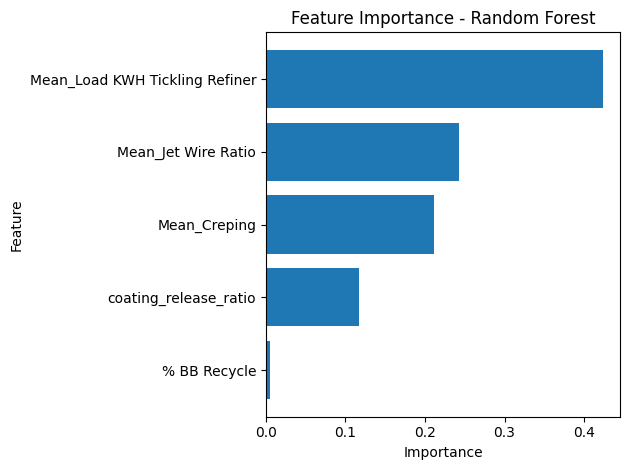

In [8]:
# Feature Importance
import pandas as pd

feat_imp = pd.DataFrame({
    "Feature": features, 
    "Importance": model.feature_importances_
})

# Urutkan dari terbesar
feat_imp = feat_imp.sort_values(by="Importance", ascending=False)


# Plot
import matplotlib.pyplot as plt
plt.figure()
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")

plt.tight_layout()
plt.show()

### SHAP Analysis

In [9]:
import shap
import numpy as np
import matplotlib.pyplot as plt

e:\Kuliah\Sun Paper Source\Y Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 28.751101, while the model output was 28.190000. If this difference is acceptable you can set check_additivity=False to disable this check.

In [11]:
shap.plots.beeswarm(shap_values, max_display=10)

NameError: name 'shap_values' is not defined

In [ ]:
# Scatter plot dasar - melihat tren arah secara mendetail
shap.plots.scatter(shap_values[:, "Mean_Load KWH Refiner"])

In [ ]:
shap.plots.scatter(shap_values[:, "% NBKP"])

In [12]:
shap_values = explainer.shap_values(np.array(X_test))
shap.initjs()
i = 0  # index data

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test.iloc[i]
)

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 28.751101, while the model output was 28.190000. If this difference is acceptable you can set check_additivity=False to disable this check.